<a href="https://colab.research.google.com/github/fabriziofdsp/Laboratorio3/blob/main/Lab3_Codif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imagecodecs

!pip install numpy==2.2.6 scipy --upgrade --force-reinstall

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [1]:
from skimage import data
from PIL import Image
import os

os.makedirs("imagenes", exist_ok=True)

img = data.astronaut()

Image.fromarray(img).save("imagenes/rostro.png")

print("Imagen guardada correctamente.")

Imagen guardada correctamente.


In [2]:
from PIL import Image
import imagecodecs
import numpy as np
import os

os.makedirs("salida", exist_ok=True)

img = Image.open("imagenes/rostro.png").convert("RGB")

# -----------------------
# JPEG
# -----------------------

qualities = [25, 50, 75, 90, 95]

for q in qualities:
    img.save(
        f"salida/jpeg_q{q}.jpg",
        format="JPEG",
        quality=q,
        subsampling="4:2:0"
    )

print("JPEG terminado")

# -----------------------
# JPEG XL
# -----------------------

arr = np.asarray(img)

distancias = [3.0, 2.0, 1.0, 0.7, 0.4]

for d in distancias:

    enc = imagecodecs.jpegxl_encode(
        arr,
        distance=d,
        effort=7
    )

    with open(f"salida/jxl_d{d}.jxl", "wb") as f:
        f.write(enc)

print("JPEG XL terminado")

JPEG terminado
JPEG XL terminado


In [7]:
import os
import pandas as pd
import numpy as np

from PIL import Image
import imagecodecs

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

In [8]:
# Imagen original

ref = np.asarray(
    Image.open("imagenes/rostro.png").convert("RGB")
)

alto, ancho = ref.shape[:2]
pixeles = alto * ancho

In [9]:
def decodificar(path):

    if path.endswith(".jpg"):
        return np.asarray(
            Image.open(path).convert("RGB")
        )

    if path.endswith(".jxl"):
        img = imagecodecs.jpegxl_decode(
            open(path, "rb").read()
        )

        return img[..., :3]

In [10]:
resultados = []

for archivo in sorted(os.listdir("salida")):

    ruta = os.path.join("salida", archivo)

    rec = decodificar(ruta)

    bytes_archivo = os.path.getsize(ruta)

    bpp = (bytes_archivo * 8) / pixeles

    ratio = (alto * ancho * 3) / bytes_archivo

    psnr = peak_signal_noise_ratio(
        ref,
        rec,
        data_range=255
    )

    ssim = structural_similarity(
        ref,
        rec,
        channel_axis=2,
        data_range=255
    )

    resultados.append([
        archivo,
        bytes_archivo,
        bpp,
        ratio,
        psnr,
        ssim
    ])

In [12]:
df = pd.DataFrame(
    resultados,
    columns=[
        "archivo",
        "bytes",
        "bpp",
        "ratio",
        "PSNR",
        "SSIM"
    ]
)

df.to_csv("resultados.csv", index=False)

df

,archivo,bytes,bpp,ratio,PSNR,SSIM
0,jpeg_q25.jpg,18876,0.576050,41.663064,29.998794,0.888923
1,jpeg_q50.jpg,27748,0.846802,28.341935,32.062728,0.920230
2,jpeg_q75.jpg,40240,1.228027,19.543539,34.001040,0.940515
3,jpeg_q90.jpg,68052,2.076782,11.556339,36.691111,0.960312
4,jpeg_q95.jpg,99308,3.030640,7.919120,38.280164,0.970004
5,jxl_d0.4.jxl,101284,3.090942,7.764622,39.872273,0.977100
6,jxl_d0.7.jxl,67466,2.058899,11.656716,38.094933,0.968479
7,jxl_d1.0.jxl,51557,1.573395,15.253642,36.978071,0.961872
8,jxl_d2.0.jxl,31283,0.954681,25.139277,34.433279,0.943111
9,jxl_d3.0.jxl,23466,0.716125,33.513679,33.009529,0.929711


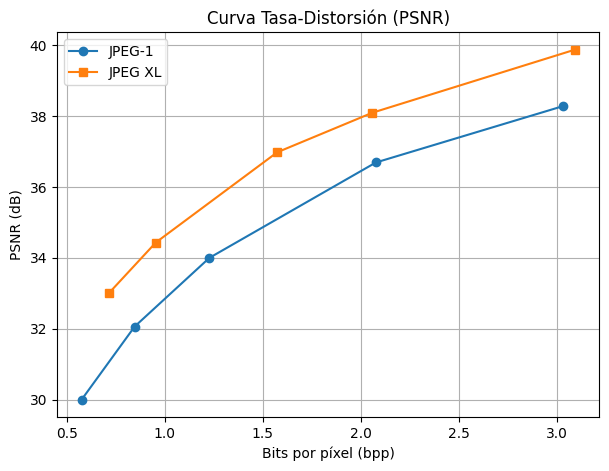

In [13]:
import matplotlib.pyplot as plt

jpeg = df[df["archivo"].str.endswith(".jpg")].sort_values("bpp")
jxl = df[df["archivo"].str.endswith(".jxl")].sort_values("bpp")

plt.figure(figsize=(7,5))

plt.plot(
    jpeg["bpp"],
    jpeg["PSNR"],
    "o-",
    label="JPEG-1"
)

plt.plot(
    jxl["bpp"],
    jxl["PSNR"],
    "s-",
    label="JPEG XL"
)

plt.xlabel("Bits por píxel (bpp)")
plt.ylabel("PSNR (dB)")
plt.title("Curva Tasa-Distorsión (PSNR)")
plt.grid(True)
plt.legend()

plt.savefig("rd_psnr.png", dpi=300)

plt.show()

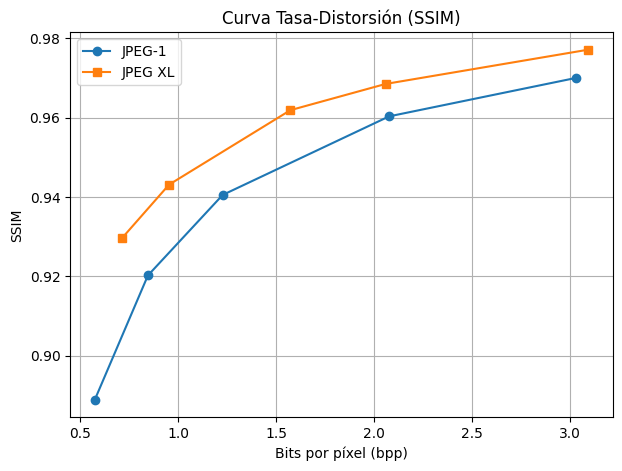

In [14]:
plt.figure(figsize=(7,5))

plt.plot(
    jpeg["bpp"],
    jpeg["SSIM"],
    "o-",
    label="JPEG-1"
)

plt.plot(
    jxl["bpp"],
    jxl["SSIM"],
    "s-",
    label="JPEG XL"
)

plt.xlabel("Bits por píxel (bpp)")
plt.ylabel("SSIM")
plt.title("Curva Tasa-Distorsión (SSIM)")
plt.grid(True)
plt.legend()

plt.savefig("rd_ssim.png", dpi=300)

plt.show()

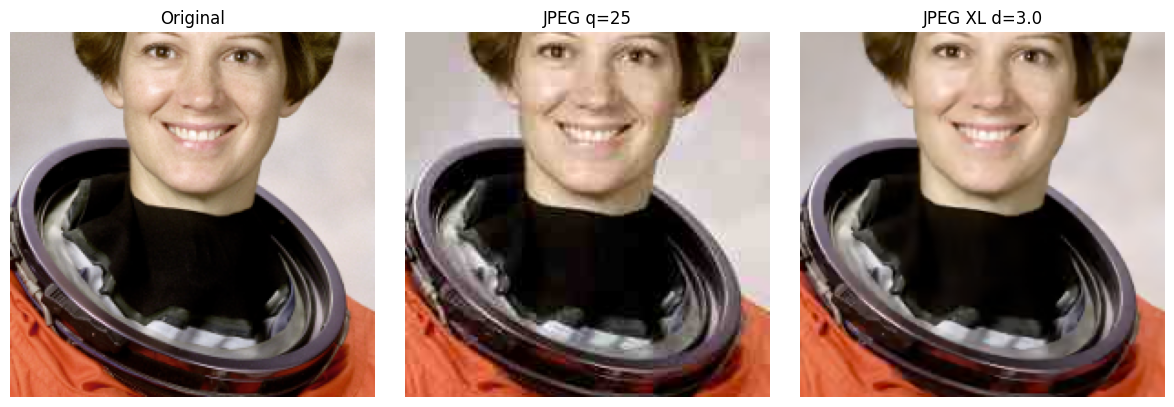

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import imagecodecs
import numpy as np

# Imagen original
ref = np.asarray(Image.open("imagenes/rostro.png").convert("RGB"))

# JPEG
jpeg = np.asarray(Image.open("salida/jpeg_q25.jpg").convert("RGB"))

# JPEG XL
jxl = imagecodecs.jpegxl_decode(
    open("salida/jxl_d3.0.jxl", "rb").read()
)[..., :3]

# Recorte de la cara
y1, y2 = 90, 290
x1, x2 = 120, 320

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(ref[y1:y2, x1:x2])
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(jpeg[y1:y2, x1:x2])
ax[1].set_title("JPEG q=25")
ax[1].axis("off")

ax[2].imshow(jxl[y1:y2, x1:x2])
ax[2].set_title("JPEG XL d=3.0")
ax[2].axis("off")

plt.tight_layout()

plt.savefig("comparacion_visual.png", dpi=300)

plt.show()